Outlier Dectection

by Josh Navarro

Goal: Learn way to detect data outliers

Data: Synthetic Data created by Chatgpt

In [24]:
# The imports that we are going to be using
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Creating the date frame
df = pd.DataFrame({
    "employee_id": range(101, 121),
    "salary": [
        52000, 55000, 51000, 58000, 56000,
        54000, 57000, 53000, 55000, 56000,
        54500, 53500, 52500, 55000, 54000,
        56000, 57000, 59000, 120000, 180000
    ],
    "hours_worked": [
        38, 40, 39, 41, 40,
        42, 38, 39, 40, 41,
        40, 39, 38, 42, 40,
        41, 39, 40, 70, 85
    ],
    "projects_completed": [
        5, 6, 5, 7, 6,
        5, 6, 5, 7, 6,
        5, 6, 5, 7, 6,
        5, 6, 7, 15, 20
    ]
})

df

,employee_id,salary,hours_worked,projects_completed
0,101,52000,38,5
1,102,55000,40,6
2,103,51000,39,5
3,104,58000,41,7
4,105,56000,40,6
5,106,54000,42,5
6,107,57000,38,6
7,108,53000,39,5
8,109,55000,40,7
9,110,56000,41,6


In [6]:
df.describe()

,employee_id,salary,hours_worked,projects_completed
count,20.00000,20.000000,20.000000,20.000000
mean,110.50000,64425.000000,43.600000,7.000000
std,5.91608,30906.597405,11.904886,3.755697
min,101.00000,51000.000000,38.000000,5.000000
25%,105.75000,53875.000000,39.000000,5.000000
50%,110.50000,55000.000000,40.000000,6.000000
75%,115.25000,57000.000000,41.000000,7.000000
max,120.00000,180000.000000,85.000000,20.000000


IQR Method

In the IQR Method you use Quartile 1 and 3 to find the Inter Quartile Range, then using that and an equation, we can find the lower bound and the upper bound. Any number that is outside the upper or lower bounds then they would be considered as outliers

In [8]:
# Lets find if there are any outliers in the salary column
# Finding the quartiles: Q1 and Q3, using the .quantile() function
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)

Q1, Q3

(np.float64(53875.0), np.float64(57000.0))

In [10]:
# Create the IQR, and using the IQR we can find the lower bound and upper bound
IQR = Q3 - Q1
lower_bound = (Q1 - (1.5 * IQR))
upper_bound = (Q3 + (1.5 * IQR))

IQR, lower_bound, upper_bound

(np.float64(3125.0), np.float64(49187.5), np.float64(61687.5))

In [15]:
# Find the values that are outide the lower bound and the upper bound
salary_out_df = df.copy()
salary_out_df['salary_outlier'] = (salary_out_df['salary'] < lower_bound) | (salary_out_df['salary'] > upper_bound)
salary_out_df[['salary', 'salary_outlier']]

,salary,salary_outlier
0,52000,False
1,55000,False
2,51000,False
3,58000,False
4,56000,False
5,54000,False
6,57000,False
7,53000,False
8,55000,False
9,56000,False


So we were able to find that the saalry in the 18th(120000) and 19th(180000) row are outliers

Z-Score Method

The z-score method uses the mean, and checks how far the value is from it using standard deviations.

In [16]:
# Check the Dataframe again
df.head()

,employee_id,salary,hours_worked,projects_completed
0,101,52000,38,5
1,102,55000,40,6
2,103,51000,39,5
3,104,58000,41,7
4,105,56000,40,6


In [19]:
# Focusing on the hours_worked Column
# Find the mean and the standard deviation
z_df = df.copy()

worked_mean = z_df['hours_worked'].mean()
worked_std = z_df['hours_worked'].std()

worked_mean, worked_std

(np.float64(43.6), np.float64(11.904886214889821))

In [20]:
# Create a column that calculates the zscore for each value.
# usign the equation = (value - mean / std)
z_df['worked_zscore'] = ((z_df['hours_worked'] - worked_mean) / worked_std)
z_df

,employee_id,salary,hours_worked,projects_completed,worked_zscore
0,101,52000,38,5,-0.470395
1,102,55000,40,6,-0.302397
2,103,51000,39,5,-0.386396
3,104,58000,41,7,-0.218398
4,105,56000,40,6,-0.302397
5,106,54000,42,5,-0.134399
6,107,57000,38,6,-0.470395
7,108,53000,39,5,-0.386396
8,109,55000,40,7,-0.302397
9,110,56000,41,6,-0.218398


In [23]:
# Use the threshhold of being above or below 3(ABS)
z_df['worked_outlier'] = (z_df['worked_zscore'].abs() > 3)
z_df[['hours_worked', 'worked_zscore', 'worked_outlier']]

,hours_worked,worked_zscore,worked_outlier
0,38,-0.470395,False
1,40,-0.302397,False
2,39,-0.386396,False
3,41,-0.218398,False
4,40,-0.302397,False
5,42,-0.134399,False
6,38,-0.470395,False
7,39,-0.386396,False
8,40,-0.302397,False
9,41,-0.218398,False


According to the zscore the only outlier would be the last row hacign 85 hours using the threshold of 3. Yet if we were to lower the threshold to 2 then row 18 would be considered as an outlier as well.

Visualization

In order to visualize outliers in the data frame we can use boxplot, histograms, and scatterplots as well, to visually see if there are any outliers.

In [25]:
# Checking the Data Frame once again
viz_df = df.copy()

viz_df.head()

,employee_id,salary,hours_worked,projects_completed
0,101,52000,38,5
1,102,55000,40,6
2,103,51000,39,5
3,104,58000,41,7
4,105,56000,40,6


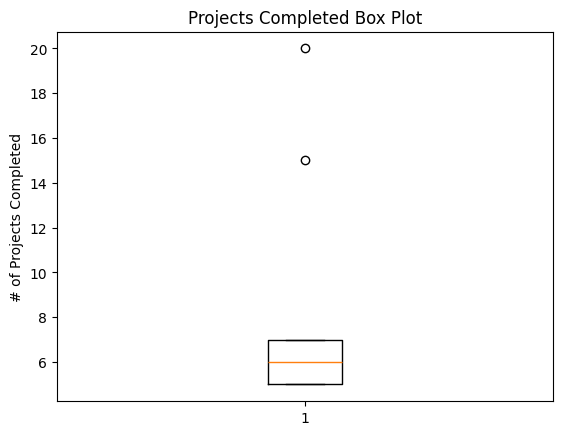

In [26]:
# Focusing on the project_complected 
# First is the boxplot, using matlotlib library

plt.figure()
plt.boxplot(viz_df['projects_completed'])
plt.title('Projects Completed Box Plot')
plt.ylabel("# of Projects Completed")
plt.show()

The dots that are outside of the box would be considerd the outliers, note that this does actually use the IQR method but visualized

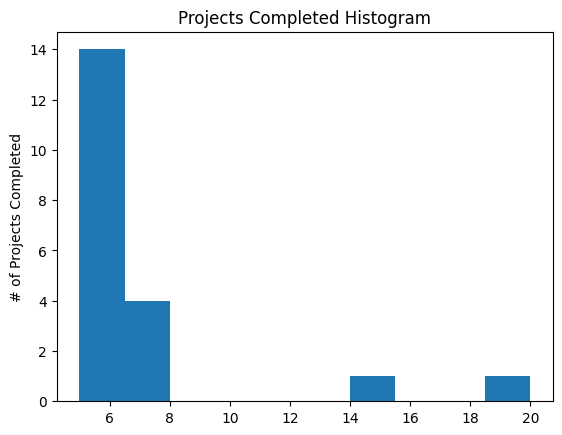

In [28]:
# Histgram

plt.figure()
plt.hist(viz_df['projects_completed'])
plt.title("Projects Completed Histogram")
plt.ylabel("# of Projects Completed")
plt.show()

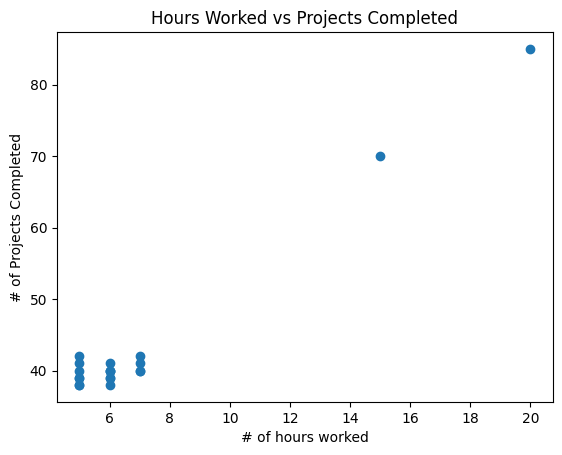

In [ ]:
# Then is the scatterplot, using the projects_completed, and then the hours_worked

plt.figure()
plt.scatter(
    viz_df['projects_completed'],
    viz_df['hours_worked']
)
plt.title("Hours Worked vs Projects Completed")
plt.ylabel("# of Projects Completed")
plt.xlabel("# of hours worked")
plt.show()

In the scatter plot we use two varaibles/columns to see the relation ship between those two columns, but also we are able to clearly see the outlier as well.